In [1]:
from math import pi

import qiskit
from qiskit_aqt_provider import AQTProvider

provider = AQTProvider()
backend = provider.offline.ideal()

circuit = qiskit.QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()

In [2]:
print(list(backend.target.operation_names))

['rz', 'r', 'rxx', 'measure']


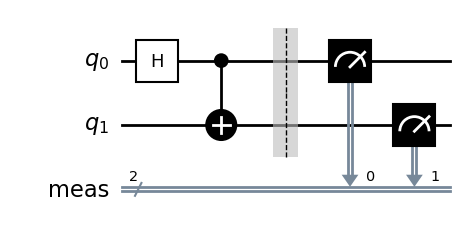

In [3]:
circuit.draw("mpl", style="bw")

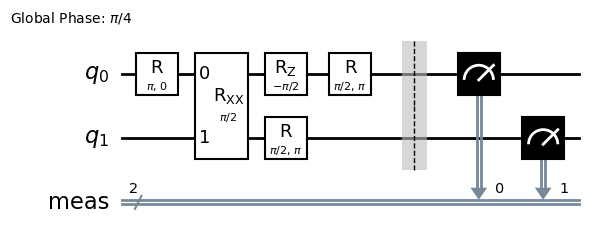

In [4]:
transpiled_circuit = qiskit.transpile(circuit, backend, optimization_level=3)
transpiled_circuit.draw("mpl", style="bw")

In [5]:
native_circuit = qiskit.QuantumCircuit(2)
native_circuit.rxx(pi/2, 0, 1)
native_circuit.r(pi, 0, 0)
native_circuit.r(pi, pi, 1)
native_circuit.measure_all()

job = backend.run(native_circuit)
result = job.result()

if result.success:
    print(result.get_counts())
else:
    raise RuntimeError

{'11': 40, '00': 60}
